Write down the steps to complete your project
•	Number of rows and columns
•	Column names
•	Data types
•	First few records
•	Basic statistical information

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
df = pd.read_excel("C:/Users/Test/Desktop/Data_Analytics/Python/Project/Movies_Rating_Dataset_Project2.xlsx")

In [6]:
df.head()

,id,original_language,popularity,vote_count,vote_average,release_date,title
0,278,en,36.1467,29384,8.714,1994-09-23,Shark Bait
1,238,en,37.3341,22174,8.686,1972-03-14,Major League II
2,240,en,14.6729,13404,8.571,1974-12-20,Aliens in the Attic
3,424,en,13.6783,16923,8.566,1993-12-15,100 Feet
4,389,en,10.6929,9589,8.548,1957-04-10,The Art of War


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   id                 10000 non-null  int64         
 1   original_language  10000 non-null  str           
 2   popularity         10000 non-null  float64       
 3   vote_count         10000 non-null  int64         
 4   vote_average       10000 non-null  float64       
 5   release_date       9998 non-null   datetime64[us]
 6   title              8580 non-null   object        
dtypes: datetime64[us](1), float64(2), int64(2), object(1), str(1)
memory usage: 547.0+ KB


In [9]:
df.columns

Index(['id', 'original_language', 'popularity', 'vote_count', 'vote_average',
       'release_date', 'title'],
      dtype='str')

Clean the Data
•	Find and handle missing values.
•	Remove duplicate records.
•	Correct incorrect data types.
•	Check for inconsistent movie or genre names.

In [10]:
# Find missing values
print(df.isnull().sum())

id                      0
original_language       0
popularity              0
vote_count              0
vote_average            0
release_date            2
title                1420
dtype: int64


In [18]:
# Remove duplicate records.
df = df.dropna()

In [19]:
# Check again
print(df.isnull().sum())

id                   0
original_language    0
popularity           0
vote_count           0
vote_average         0
release_date         0
title                0
dtype: int64


In [21]:
#Correct incorrect data types.
print(df.dtypes)

id                            int64
original_language               str
popularity                  float64
vote_count                    int64
vote_average                float64
release_date         datetime64[us]
title                        object
dtype: object


In [22]:
#Check for inconsistent movie names
print("Unique Movie Names:")
print(df["title"].unique())

Unique Movie Names:
['Shark Bait' 'Major League II' 'Aliens in the Attic' ...
 'Star Trek V: The Final Frontier' 'The Lost Prince' 'Let Us Prey']


In [ ]:
#Remove extra spaces
df["title"] = df["title"].str.strip()

In [ ]:
#Check again
print(df["title"].unique())

['Shark Bait' 'Major League II' 'Aliens in the Attic' ...
 'Star Trek V: The Final Frontier' 'The Lost Prince' 'Let Us Prey']


In [29]:
#Title format proper format
df["title"] = df["title"].str.title()

print(df.title)

0                Shark Bait
1           Major League Ii
2       Aliens In The Attic
3                  100 Feet
4            The Art Of War
               ...         
8575            Bulletproof
8576            Rough Night
8577                Haywire
8578             Prom Night
8579               The Thaw
Name: title, Length: 8578, dtype: object


Analyze the Data Perform analysis such as:
•	Average movie rating
•	Highest-rated movies
•	Lowest-rated movies
•	Most-voted movies
•	Number of movies in each id

In [ ]:
#Average movie rating
average_rating = df["vote_average"].mean()

print("Average Movie Rating:", average_rating)

#Two decimal Place
print("Average Movie Rating:", round(df["vote_average"].mean(), 2))

Average Movie Rating: 6.88276964327349
Average Movie Rating: 6.88


In [38]:
#Highest-rated movies
highest_rated = df.sort_values("vote_average", ascending=False)

print(highest_rated[["title", "vote_average"]].head(10))

                     title  vote_average
0               Shark Bait         8.714
1          Major League Ii         8.686
2      Aliens In The Attic         8.571
3                 100 Feet         8.566
4           The Art Of War         8.548
5              Nine Months         8.533
6                 Timeline         8.524
8                Skiptrace         8.503
7                 Redcon-1         8.500
9  47 Meters Down: Uncaged         8.496


In [39]:
#Lowest-rated movies
lowest_rated = df.sort_values("vote_average", ascending=True)

print(lowest_rated[["title", "vote_average"]].head(10))

                       title  vote_average
8572   Billionaire Boys Club         5.900
8571             The Getaway         5.900
8579                The Thaw         5.947
8577                 Haywire         5.947
8578              Prom Night         5.947
8576             Rough Night         5.948
8573                  Tarzan         5.948
8574  Quarantine 2: Terminal         5.948
8575             Bulletproof         5.948
8570               Hall Pass         5.949


In [40]:
#Mosted - Voted Movies 
most_voted = df.sort_values("vote_count", ascending=False)

print(most_voted[["title", "vote_count"]].head(10))

                         title  vote_count
14      Quarantine 2: Terminal       38436
41                Interstellar       38375
6                     Timeline       34849
465                      Finch       34558
1038         Spies In Disguise       32998
964   A Streetcar Named Desire       32153
93                     Le Trou       31232
20    The Shawshank Redemption       31114
11                 The Getaway       29404
0                   Shark Bait       29384


In [ ]:
#Id average ratings
avg_rating = df.groupby("id")["vote_average"].mean()

print(avg_rating)

id
2          7.100
3          7.300
6          6.500
11         8.203
12         7.817
           ...  
1356039    8.276
1363123    6.644
1376434    7.856
1422096    6.769
1426776    7.791
Name: vote_average, Length: 8573, dtype: float64


In [ ]:
#Number of movies in each id. 
movie_count = df["id"].value_counts()

print(movie_count)

id
319373    2
842924    2
58857     2
82695     2
433808    2
         ..
11775     1
10204     1
531306    1
98357     1
87101     1
Name: count, Length: 8573, dtype: int64


Step 6: Create Visualizations
Create charts such as:
•	Bar chart for top-rated movies
•	Bar chart for genre-wise ratings
•	Histogram for movie ratings
•	Scatter plot for ratings and number of votes

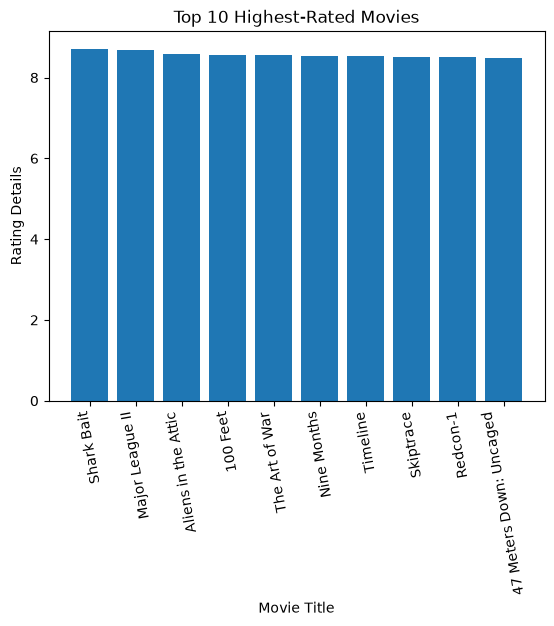

In [11]:
#Bar chart for top-rated movies
top_rated = df.sort_values("vote_average", ascending=False).head(10)

plt.bar(top_rated["title"], top_rated["vote_average"])

plt.xlabel("Movie Title")
plt.ylabel("Rating Details")

plt.title("Top 10 Highest-Rated Movies")
plt.xticks(rotation=100)
plt.show()

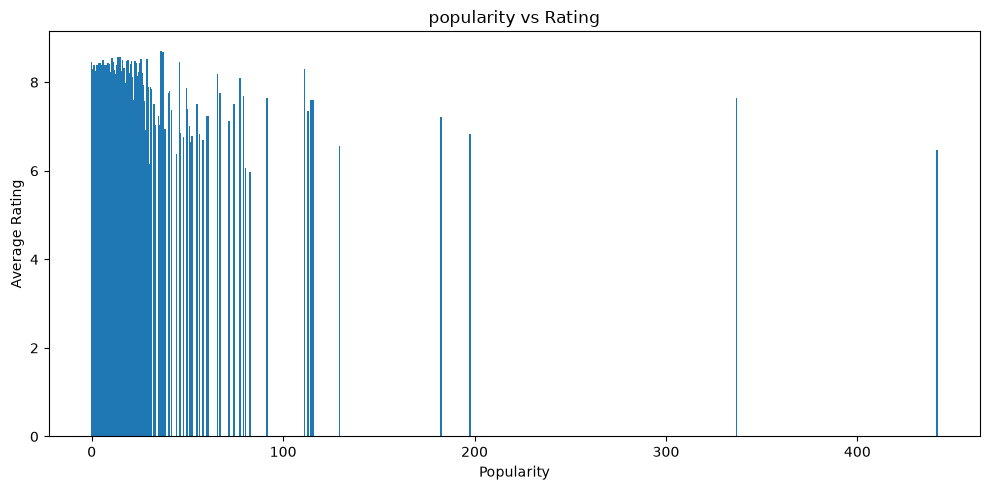

In [14]:
#Bar chart for popularity ratings

plt.figure(figsize=(10, 5))

plt.bar(df["popularity"],df["vote_average"])

plt.xlabel("Popularity")
plt.ylabel("Average Rating")
plt.title("popularity vs Rating")

plt.tight_layout()
plt.show()

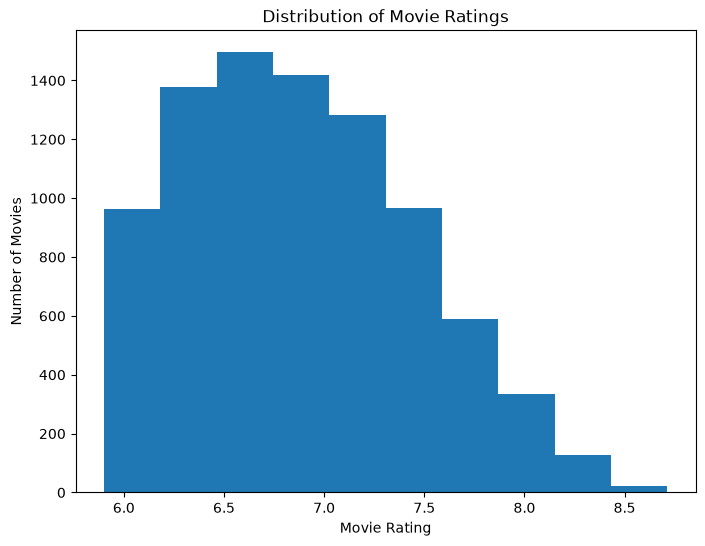

In [79]:
#Histogram for movie ratings
plt.figure(figsize=(8, 6))

plt.hist(df["vote_average"], bins=10)

plt.xlabel("Movie Rating")
plt.ylabel("Number of Movies")
plt.title("Distribution of Movie Ratings")

plt.show()

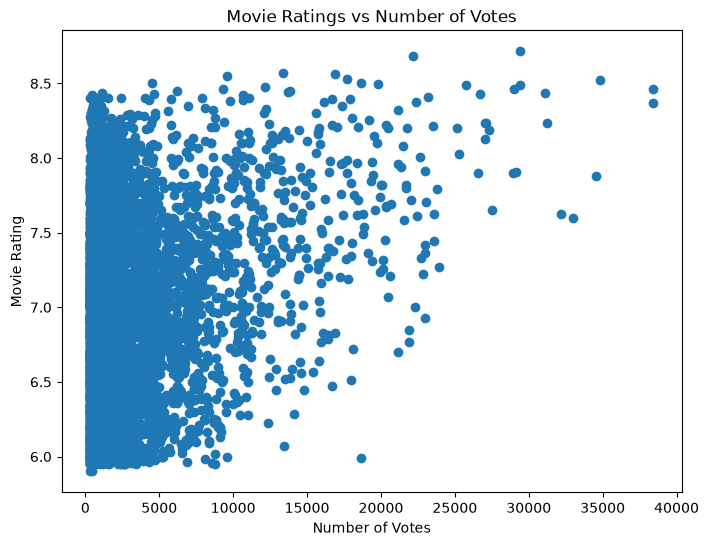

In [ ]:
#Scatter plot for ratings and number of votes

plt.figure(figsize=(8, 6))

plt.scatter(df["vote_count"], df["vote_average"])

plt.xlabel("Number of Votes")
plt.ylabel("Movie Rating")
plt.title("Movie Ratings vs Number of Votes")

plt.tight_layout()
plt.show()